In [ ]:
# imports
import os, glob, math
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
plt.rcParams['figure.figsize'] = (12,5)
print("TF", tf.__version__)


TF 2.20.0


In [ ]:
# Data is in Drive, mount it.
from google.colab import drive
drive.mount('/content/drive')

# Set base folder where your dataset is.
BASE_DIR = '/content/drive/MyDrive/major_data'
os.makedirs(BASE_DIR, exist_ok=True)
print("BASE_DIR:", BASE_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/major_data


In [ ]:
# Use the cleaned folder path
csv_files = glob.glob("/content/drive/MyDrive/major_data/cleaned/*.csv")
print("CSV files found:", csv_files)

processed_data = {}

for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)

    print(f"{company_name} raw shape: {df.shape}")  # Check if file has rows/columns

    # Only keep if df is not empty
    if df.shape[0] > 0:
        processed_data[company_name] = df

print("Companies loaded:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [ ]:
# Paths
cleaned_folder = "/content/drive/MyDrive/major_data/cleaned"
csv_files = glob.glob(os.path.join(cleaned_folder, "*.csv"))
print("CSV files found:", csv_files)

# Create output folder
output_folder = "/content/drive/MyDrive/major_data/processed_with_features"
os.makedirs(output_folder, exist_ok=True)

# Processed data dictionary
processed_data = {}

# Loop through CSVs
for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)
    print(f"{company_name} raw shape: {df.shape}")

    # Standardize column names
    df.columns = df.columns.str.strip().str.capitalize()

    # Rename inconsistent columns if needed
    rename_dict = {'Date ': 'Date', 'Close': 'Close', 'Volume': 'Volume'}
    df.rename(columns=rename_dict, inplace=True)

    # Keep only necessary columns
    required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[[col for col in df.columns if col in required_cols]]

    # Convert numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

    # Handle missing data
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)

    # Convert Date to datetime & sort
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.dropna(subset=['Date'], inplace=True)
    df = df.sort_values('Date').reset_index(drop=True)

    print(f"{company_name} rows after numeric conversion: {df.shape[0]}")

    # Skip if not enough rows
    if df.shape[0] < 5:  # can adjust threshold based on your feature window
        print(f" Skipping {company_name}, not enough rows")
        continue


    # Feature creation for LSTM
    df['Return'] = df['Close'].pct_change()
    df['High_Low'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close'] = (df['Open'] - df['Close']) / df['Close']
    df['Volume_Change'] = df['Volume'].pct_change()

    # Drop first row which has NaN from pct_change
    df.dropna(inplace=True)

    # Save processed data
    processed_data[company_name] = df
    print(f" Features created for {company_name}: {df.shape}")

    output_file_path = os.path.join(output_folder, f"{company_name}_features.csv")
    df.to_csv(output_file_path, index=False)
    print(f"Saved processed file with features: {output_file_path}")

# Summary
print("Companies ready:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [ ]:
# GRU independent model starts

In [ ]:
pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 57.0 MB/s eta 0:00:00


In [ ]:
import talib

for company, df in processed_data.items():
    df = df.copy()

    # Basic features
    df['Return'] = df['Close'].pct_change()
    df['High_Low'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close'] = (df['Open'] - df['Close']) / df['Close']
    df['Volume_Change'] = df['Volume'].pct_change()

    # Lag features (previous 1–3 days Close)
    for lag in range(1, 4):
        df[f'Close_lag{lag}'] = df['Close'].shift(lag)

    # Rolling statistics
    df['MA_5'] = df['Close'].rolling(5).mean()
    df['MA_10'] = df['Close'].rolling(10).mean()
    df['STD_5'] = df['Close'].rolling(5).std()

    # Technical Indicators
    df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

    df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'])

    # Remove NaN values created by rolling indicators
    df.dropna(inplace=True)

    processed_data[company] = df

    print(f"{company} features updated: {df.shape}")

Adani Enterprises Ltd features updated: (2726, 20)
Adani ports and special Economic features updated: (2726, 20)
Bajaj Finance Ltd features updated: (2726, 20)
Axis Bank Ltd features updated: (2730, 20)
Bajaj Finserv Ltd features updated: (2726, 20)
Bharat Electronics Ltd features updated: (1109, 20)
Bharti Airtel Ltd features updated: (2726, 20)
Eternal Ltd features updated: (2726, 20)
HCL Technologies Ltd features updated: (2721, 20)
HDFC Bank Ltd features updated: (2726, 20)
Hindustan Unilever Ltd features updated: (2726, 20)
ICICI Bank Ltd features updated: (2726, 20)
ITC Ltd features updated: (2726, 20)
Infosys Ltd features updated: (2726, 20)
JSW Steel Ltd features updated: (2726, 20)
Larsen and Toubro Ltd features updated: (2726, 20)
Kotak Mahindra Bank Ltd features updated: (2721, 20)
Mahindra and Mahindra Ltd features updated: (2726, 20)
Maruti Suzuki India Ltd features updated: (2726, 20)
NTPC Ltd features updated: (2726, 20)
Oil and Natural Gas Corporation Ltd features updat

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

timesteps = 10
all_gru_models = {}

# Same feature columns
feature_columns = [col for col in processed_data['Reliance Industries Ltd'].columns if col != 'Date']

for company, df in processed_data.items():

    n = len(df)
    train_size = int(n * 0.7)
    val_size = int(n * 0.15)

    train_df = df.iloc[:train_size]
    val_df   = df.iloc[train_size:train_size + val_size]
    test_df  = df.iloc[train_size + val_size:]

    # -------- Feature Scaling (different scaler for GRU) --------
    feature_scaler = StandardScaler()

    X_train_scaled = feature_scaler.fit_transform(train_df[feature_columns])
    X_val_scaled   = feature_scaler.transform(val_df[feature_columns])
    X_test_scaled  = feature_scaler.transform(test_df[feature_columns])

    # -------- Target Scaling --------
    target_scaler = StandardScaler()

    y_train_scaled = target_scaler.fit_transform(train_df[['Close']])
    y_val_scaled   = target_scaler.transform(val_df[['Close']])
    y_test_scaled  = target_scaler.transform(test_df[['Close']])

    # -------- Sequence Creation --------
    def create_sequences(X, y, timesteps):
        X_seq, y_seq = [], []

        for i in range(timesteps, len(X)):
            X_seq.append(X[i - timesteps:i])
            y_seq.append(y[i])

        return np.array(X_seq), np.array(y_seq)

    X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, timesteps)
    X_val, y_val     = create_sequences(X_val_scaled, y_val_scaled, timesteps)
    X_test, y_test   = create_sequences(X_test_scaled, y_test_scaled, timesteps)

    all_gru_models[company] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'timesteps': timesteps,
        'feature_columns': feature_columns
    }

    print(f"{company}: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

Adani Enterprises Ltd: Train=1898, Val=398, Test=400
Adani ports and special Economic: Train=1898, Val=398, Test=400
Bajaj Finance Ltd: Train=1898, Val=398, Test=400
Axis Bank Ltd: Train=1900, Val=399, Test=401
Bajaj Finserv Ltd: Train=1898, Val=398, Test=400
Bharat Electronics Ltd: Train=766, Val=156, Test=157
Bharti Airtel Ltd: Train=1898, Val=398, Test=400
Eternal Ltd: Train=1898, Val=398, Test=400
HCL Technologies Ltd: Train=1894, Val=398, Test=399
HDFC Bank Ltd: Train=1898, Val=398, Test=400
Hindustan Unilever Ltd: Train=1898, Val=398, Test=400
ICICI Bank Ltd: Train=1898, Val=398, Test=400
ITC Ltd: Train=1898, Val=398, Test=400
Infosys Ltd: Train=1898, Val=398, Test=400
JSW Steel Ltd: Train=1898, Val=398, Test=400
Larsen and Toubro Ltd: Train=1898, Val=398, Test=400
Kotak Mahindra Bank Ltd: Train=1894, Val=398, Test=399
Mahindra and Mahindra Ltd: Train=1898, Val=398, Test=400
Maruti Suzuki India Ltd: Train=1898, Val=398, Test=400
NTPC Ltd: Train=1898, Val=398, Test=400
Oil and Nat

In [ ]:
MODEL_TAG = "gru_independent"

# Folders to save GRU models, history, and plots
GRU_INDEPENDENT = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT"
os.makedirs(GRU_INDEPENDENT, exist_ok=True)

GRU_MODEL_DIR = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_models_independent"
os.makedirs(GRU_MODEL_DIR, exist_ok=True)

GRU_HIST_DIR = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_history"
os.makedirs(GRU_HIST_DIR, exist_ok=True)

GRU_PLOT_DIR = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots"
os.makedirs(GRU_PLOT_DIR, exist_ok=True)

GRU_METRICS_DIR = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_metrics"
os.makedirs(GRU_METRICS_DIR, exist_ok=True)

In [ ]:
import os
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

MODEL_TAG = "gru_independent_model"

# Training hyperparameters
epochs = 100
batch_size = 32

for company, data in all_gru_models.items():

    company_safe = company.replace(" ", "_")

    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']

    # -------- GRU Independent Model Architecture --------
    gru_ind_model = Sequential([
        GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),

        GRU(32),
        Dropout(0.2),

        Dense(1)
    ])

    gru_ind_model.compile(
        optimizer='adam',
        loss='mse'
    )

    # -------- Early Stopping --------
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )

    # -------- Training --------
    history_gru_ind = gru_ind_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    # -------- Save model & history in dictionary --------
    data['gru_ind_model'] = gru_ind_model
    data['gru_ind_history'] = history_gru_ind.history

    # -------- Save history file --------
    history_file = os.path.join(GRU_HIST_DIR, f"{company_safe}_gru_ind_history.pkl")

    with open(history_file, "wb") as f:
        pickle.dump(history_gru_ind.history, f)

    print(f" GRU Independent model trained and saved for {company}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1695 - val_loss: 0.2216
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0453 - val_loss: 0.1518
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0355 - val_loss: 0.0894
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0284 - val_loss: 0.0589
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0236 - val_loss: 0.0636
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0268 - val_loss: 0.0550
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0233 - val_loss: 0.0515
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0201 - val_loss: 0.0482
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0198 - val_loss: 0.0615
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0191 - val_loss: 0.0482
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0180 - val_loss: 0.0372
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - los

In [ ]:
import os
import json
import joblib

# Save GRU Independent model, directory
GRU_IND_MODEL_DIR = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_models_independent"
os.makedirs(GRU_IND_MODEL_DIR, exist_ok=True)

for company, data in all_gru_models.items():

    safe_name = company.replace(" ", "_").replace(".", "")
    company_dir = os.path.join(GRU_IND_MODEL_DIR, safe_name)
    os.makedirs(company_dir, exist_ok=True)

    # -------- Save GRU Independent Model --------
    model_path = os.path.join(company_dir, "gru_ind_model.keras")
    data['gru_ind_model'].save(model_path)

    # -------- Save scalers --------
    joblib.dump(
        data['feature_scaler'],
        os.path.join(company_dir, "feature_scaler.pkl")
    )

    joblib.dump(
        data['target_scaler'],
        os.path.join(company_dir, "target_scaler.pkl")
    )

    # -------- Save metadata --------
    metadata = {
        "timesteps": data['timesteps'],
        "feature_columns": data['feature_columns']
    }

    with open(os.path.join(company_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=4)

    print(f"Saved GRU Independent model & scalers for {company}")

Saved GRU Independent model & scalers for Adani Enterprises Ltd
Saved GRU Independent model & scalers for Adani ports and special Economic
Saved GRU Independent model & scalers for Bajaj Finance Ltd
Saved GRU Independent model & scalers for Axis Bank Ltd
Saved GRU Independent model & scalers for Bajaj Finserv Ltd
Saved GRU Independent model & scalers for Bharat Electronics Ltd
Saved GRU Independent model & scalers for Bharti Airtel Ltd
Saved GRU Independent model & scalers for Eternal Ltd
Saved GRU Independent model & scalers for HCL Technologies Ltd
Saved GRU Independent model & scalers for HDFC Bank Ltd
Saved GRU Independent model & scalers for Hindustan Unilever Ltd
Saved GRU Independent model & scalers for ICICI Bank Ltd
Saved GRU Independent model & scalers for ITC Ltd
Saved GRU Independent model & scalers for Infosys Ltd
Saved GRU Independent model & scalers for JSW Steel Ltd
Saved GRU Independent model & scalers for Larsen and Toubro Ltd
Saved GRU Independent model & scalers for

In [ ]:
import os
import matplotlib.pyplot as plt

for company, data in all_gru_models.items():

    safe_name = company.replace(" ", "_").replace(".", "")
    history = data['gru_ind_history']   # GRU Independent history

    # Plot training history
    plt.figure(figsize=(8,5))

    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')

    plt.title(f"{company} GRU Independent Model Training History")
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')

    plt.legend()
    plt.grid(True)

    # Save plot
    plot_path = os.path.join(GRU_HIST_DIR, f"{safe_name}_gru_ind_history.png")

    plt.savefig(plot_path)
    plt.close()

    print(f"GRU Independent training history plot saved for {company}")

GRU Independent training history plot saved for Adani Enterprises Ltd
GRU Independent training history plot saved for Adani ports and special Economic
GRU Independent training history plot saved for Bajaj Finance Ltd
GRU Independent training history plot saved for Axis Bank Ltd
GRU Independent training history plot saved for Bajaj Finserv Ltd
GRU Independent training history plot saved for Bharat Electronics Ltd
GRU Independent training history plot saved for Bharti Airtel Ltd
GRU Independent training history plot saved for Eternal Ltd
GRU Independent training history plot saved for HCL Technologies Ltd
GRU Independent training history plot saved for HDFC Bank Ltd
GRU Independent training history plot saved for Hindustan Unilever Ltd
GRU Independent training history plot saved for ICICI Bank Ltd
GRU Independent training history plot saved for ITC Ltd
GRU Independent training history plot saved for Infosys Ltd
GRU Independent training history plot saved for JSW Steel Ltd
GRU Independent

In [ ]:
# EVALUATION
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Folder to save metrics
GRU_IND_METRICS_DIR = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_ind_metrics"
os.makedirs(GRU_IND_METRICS_DIR, exist_ok=True)

metrics_list = []

for company, data in all_gru_models.items():

    model = data['gru_ind_model']   #  GRU Independent model
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    # -------- Predictions --------
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    # -------- Metrics --------
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # -------- Store in master list --------
    metrics_list.append({
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    })

    # -------- Save individual company metrics --------
    company_metrics_df = pd.DataFrame([{
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    }])

    company_safe = company.replace(" ", "_")

    company_metrics_df.to_csv(
        os.path.join(GRU_IND_METRICS_DIR, f"{company_safe}_gru_ind_metrics.csv"),
        index=False
    )

# -------- Save combined metrics --------
metrics_df = pd.DataFrame(metrics_list)

metrics_df.to_csv(
    os.path.join(GRU_IND_METRICS_DIR, "A_gru_ind_test_metrics.csv"),
    index=False
)

print(" GRU Independent metrics saved (combined + individual files).")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
 GRU Independent metrics saved (combined

In [ ]:
for company, data in all_gru_models.items():

    model = data['gru_ind_model']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = model.predict(X_test)

    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    print(f"{company}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print("-"*40)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Adani Enterprises Ltd
RMSE: 95.40
MAE : 65.95
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Adani ports and special Economic
RMSE: 30.46
MAE : 26.39
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Bajaj Finance Ltd
RMSE: 459.16
MAE : 191.51
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Axis Bank Ltd
RMSE: 178.04
MAE : 165.17
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Bajaj Finserv Ltd
RMSE: 198.38
MAE : 148.67
----------------------------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Bharat Electronics Ltd
RMSE: 22.70
MAE : 20.62
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Bharti Airtel Ltd
RMSE: 863.33
MAE : 839.79
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Eternal Ltd
RMSE: 34.66
MAE : 28.65
--------------------------------------

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


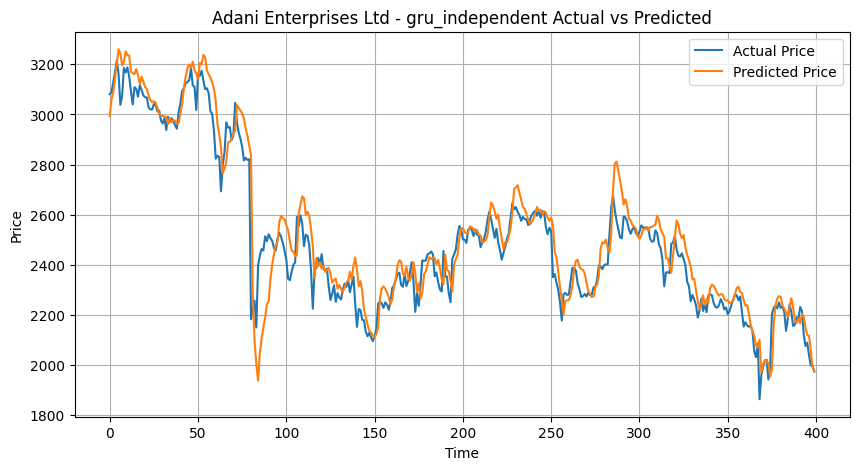

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Adani_Enterprises_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


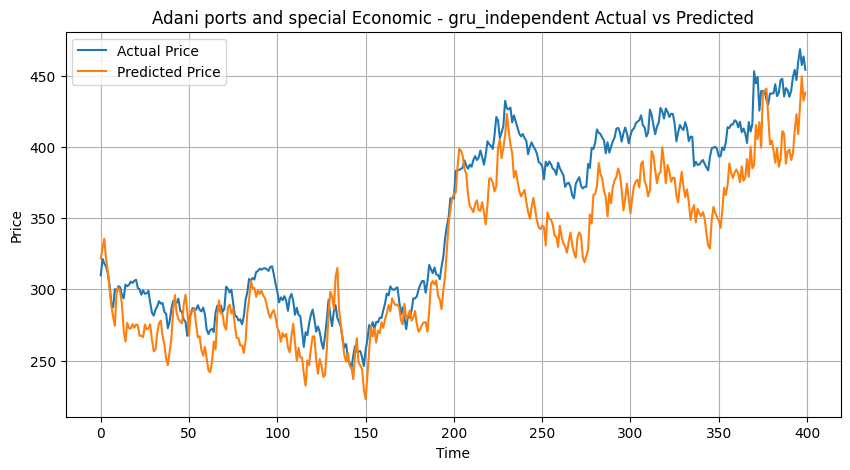

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Adani_ports_and_special_Economic_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


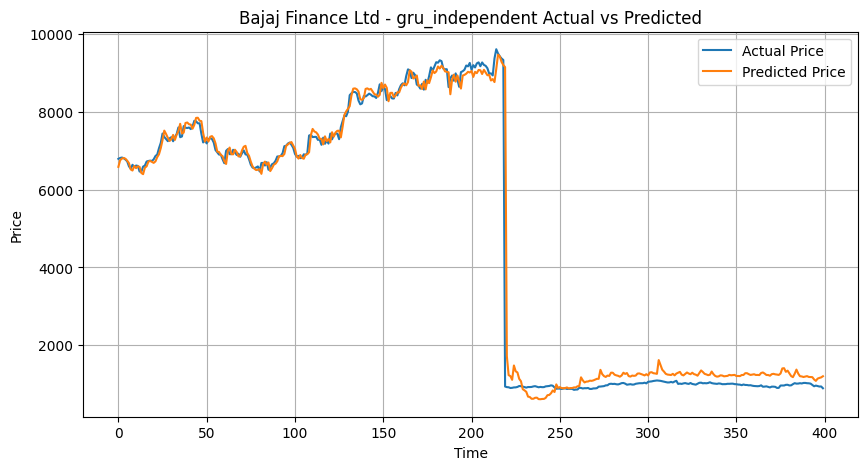

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Bajaj_Finance_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


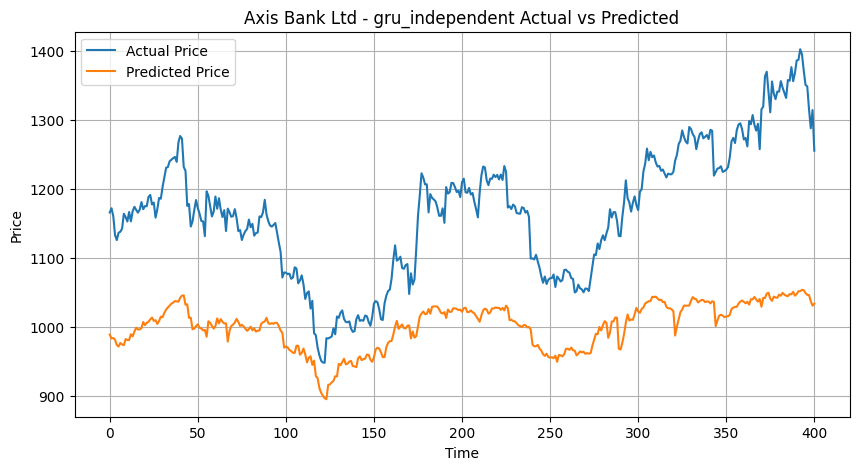

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Axis_Bank_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


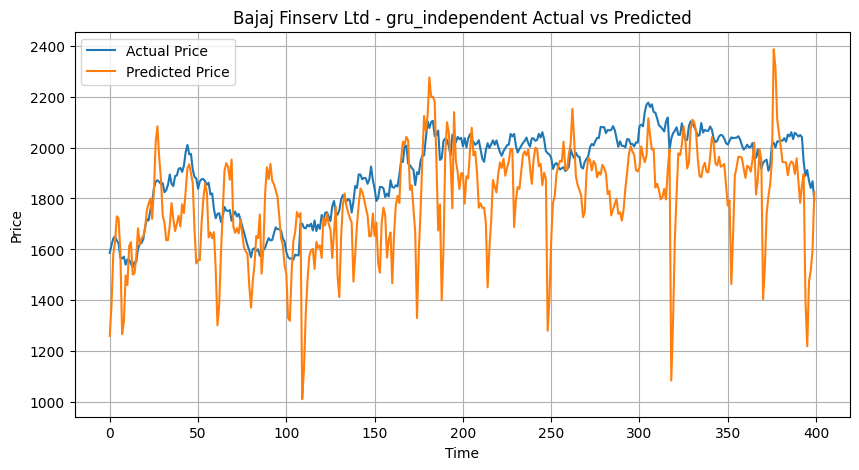

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Bajaj_Finserv_Ltd_gru_independent_actual_vs_pred.png
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


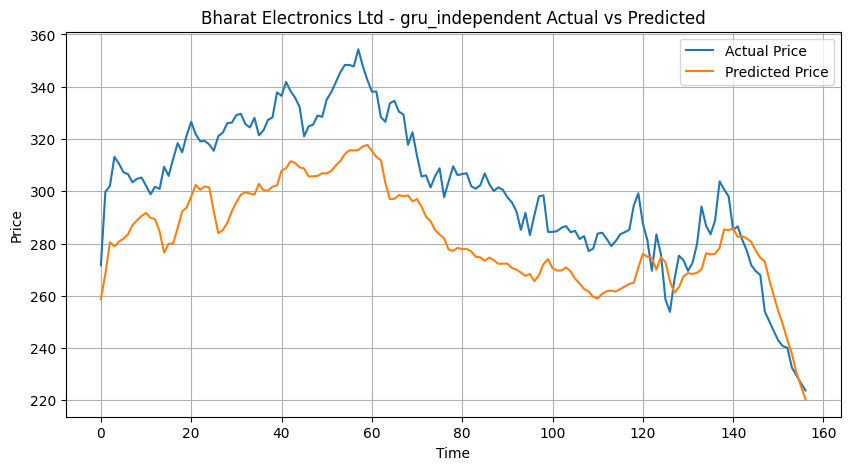

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Bharat_Electronics_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


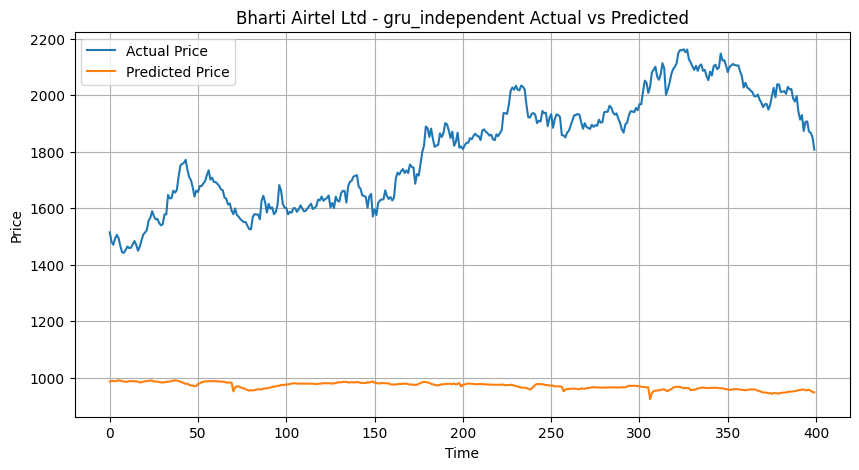

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Bharti_Airtel_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


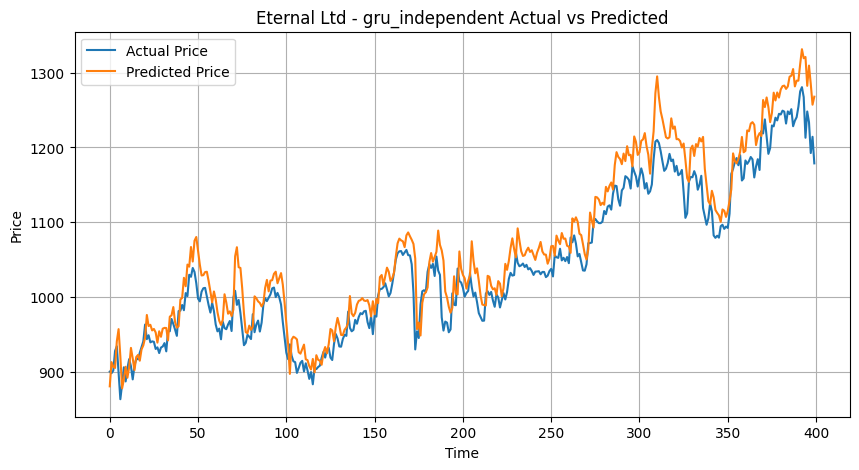

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Eternal_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


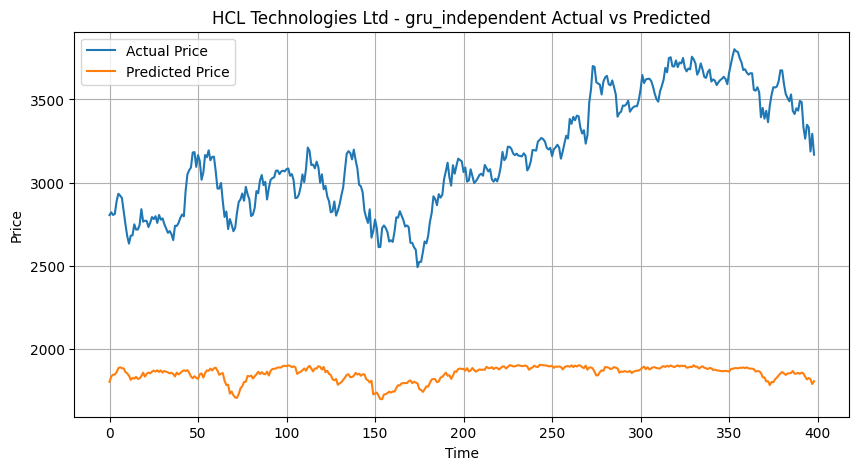

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/HCL_Technologies_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


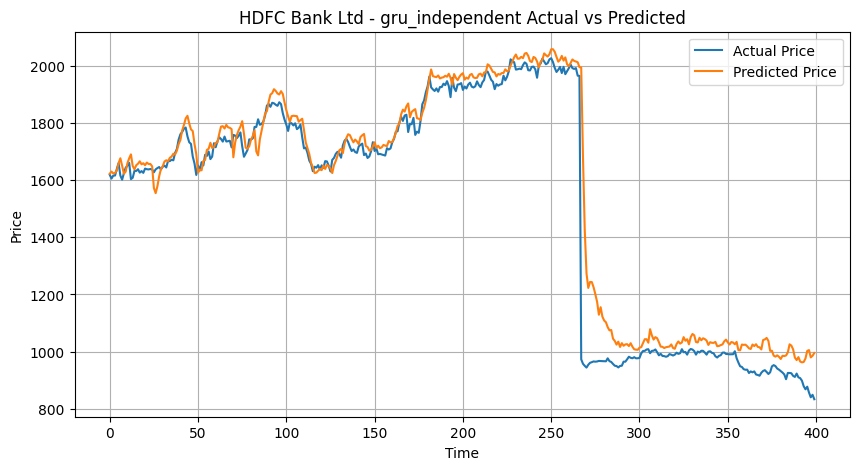

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/HDFC_Bank_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


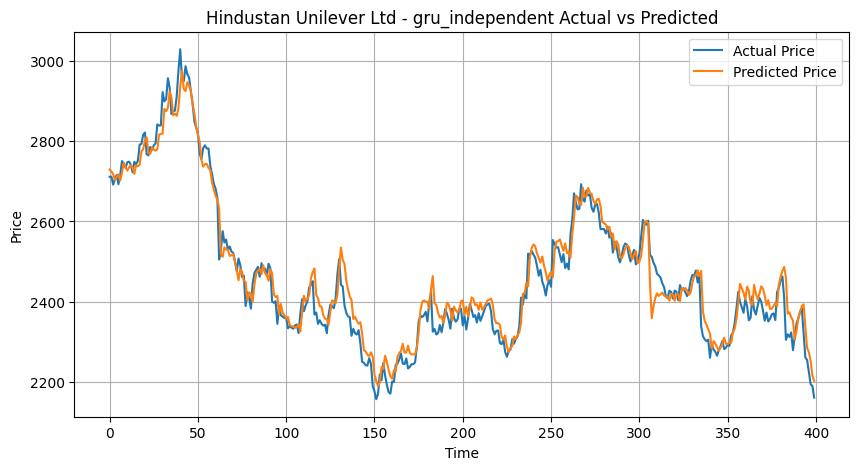

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Hindustan_Unilever_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


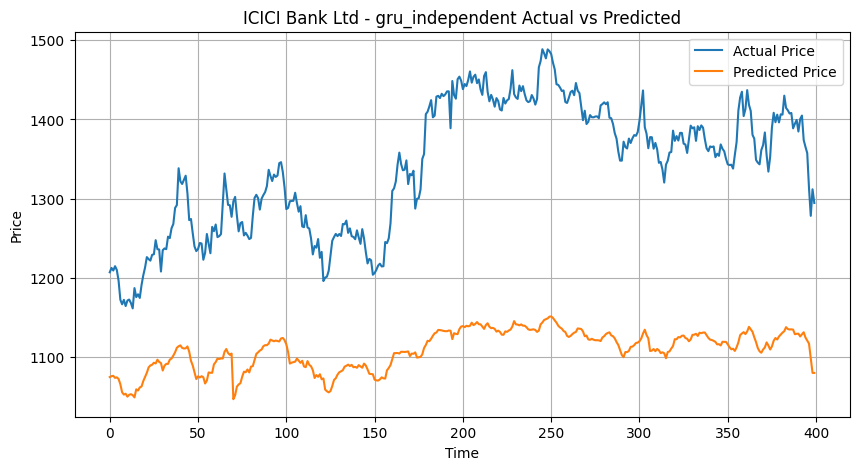

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/ICICI_Bank_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


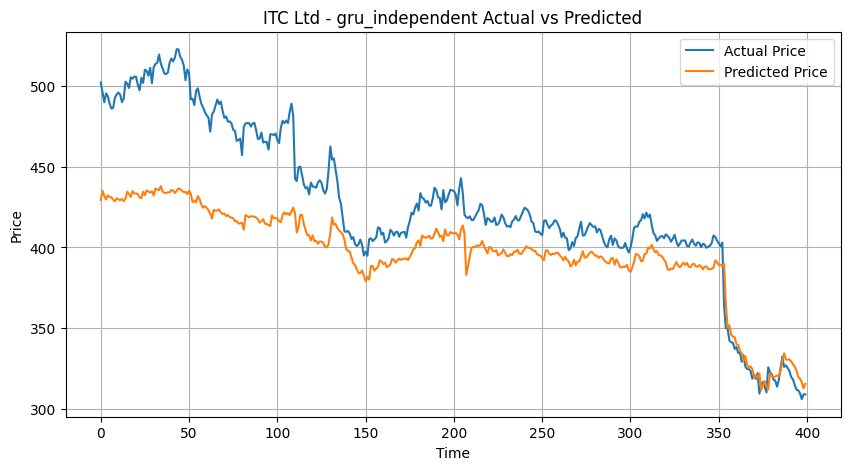

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/ITC_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


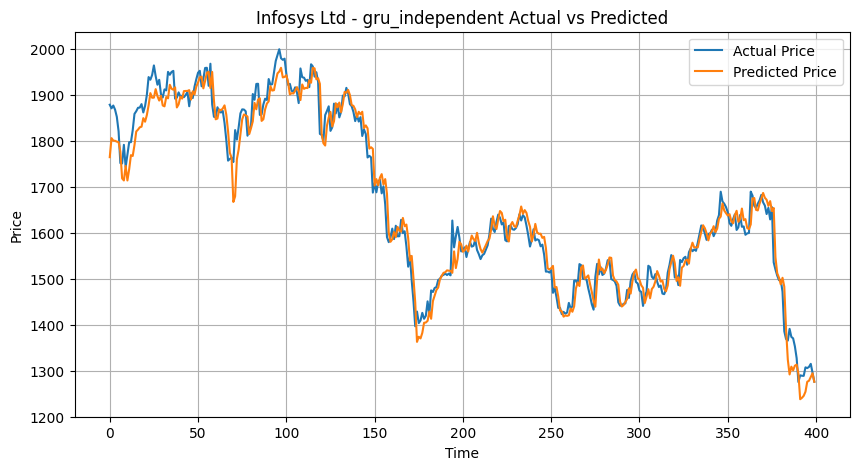

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Infosys_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


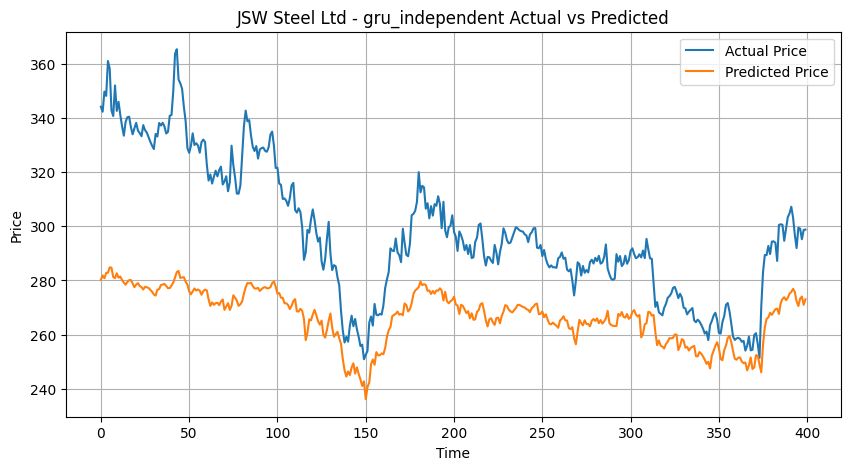

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/JSW_Steel_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


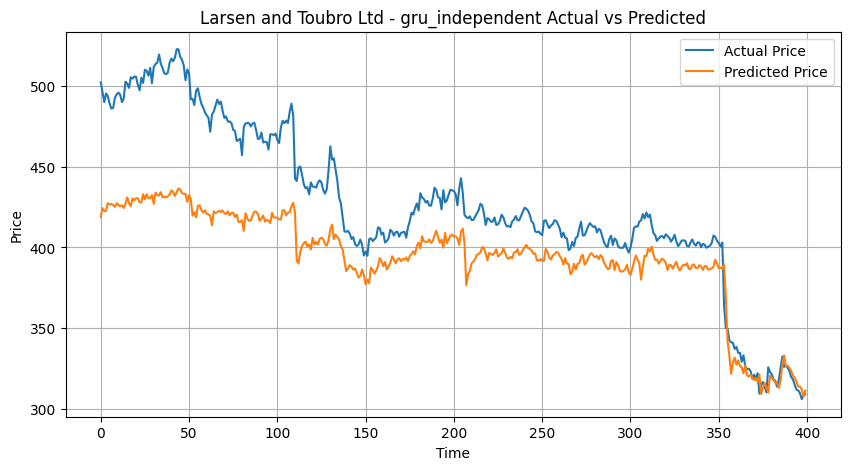

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Larsen_and_Toubro_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


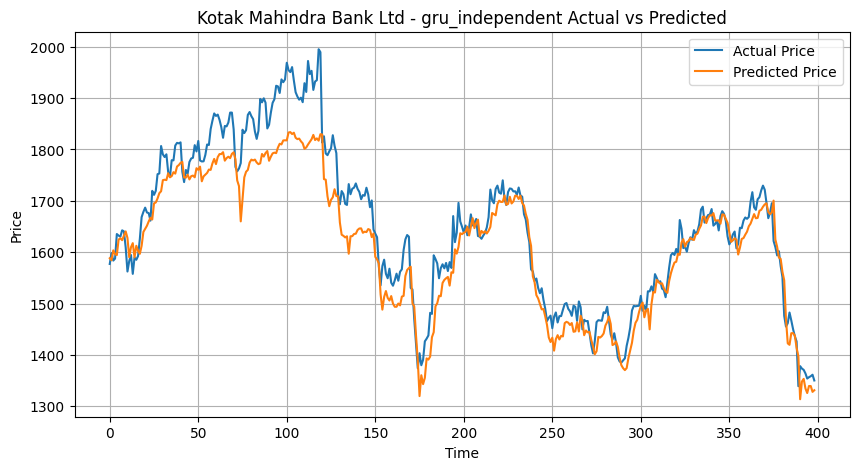

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Kotak_Mahindra_Bank_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


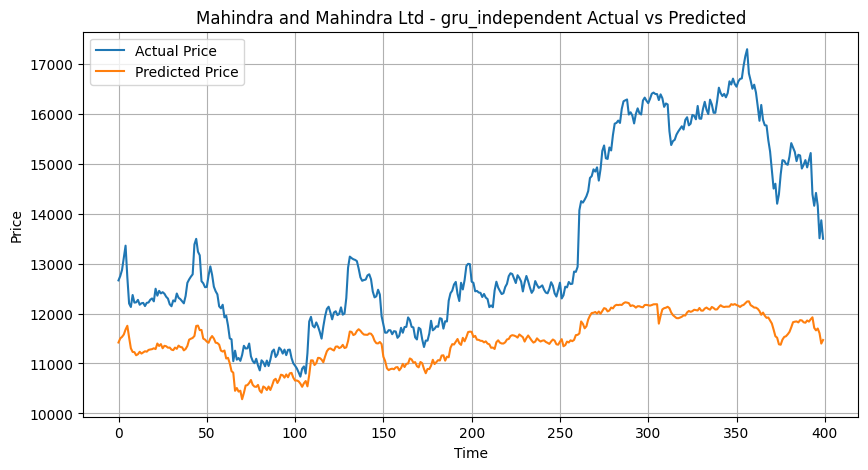

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Mahindra_and_Mahindra_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


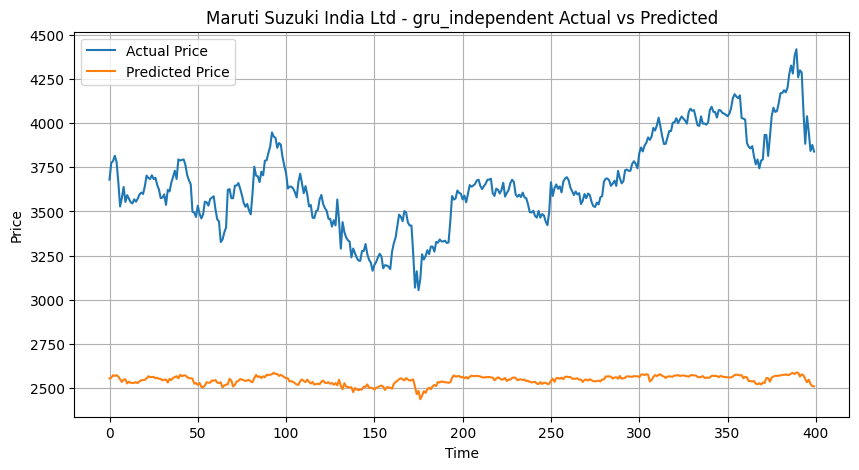

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Maruti_Suzuki_India_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


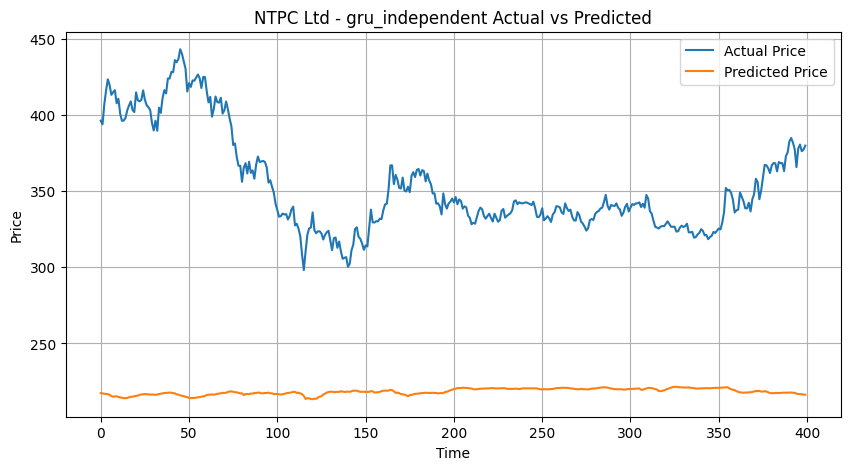

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/NTPC_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


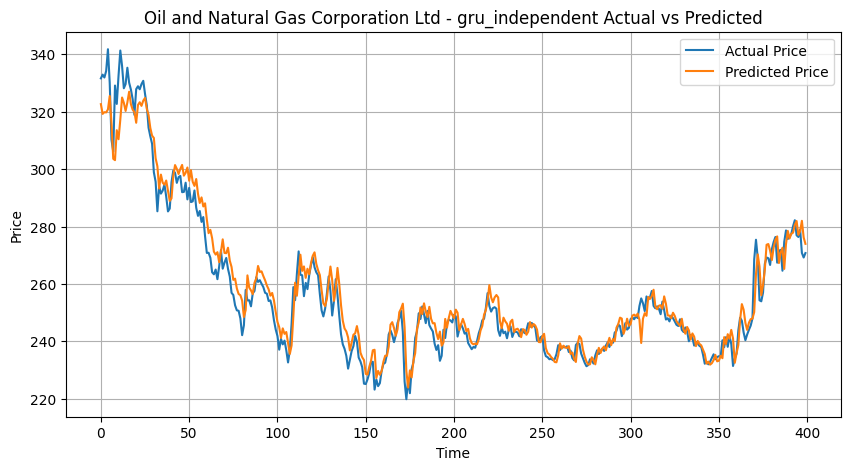

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Oil_and_Natural_Gas_Corporation_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


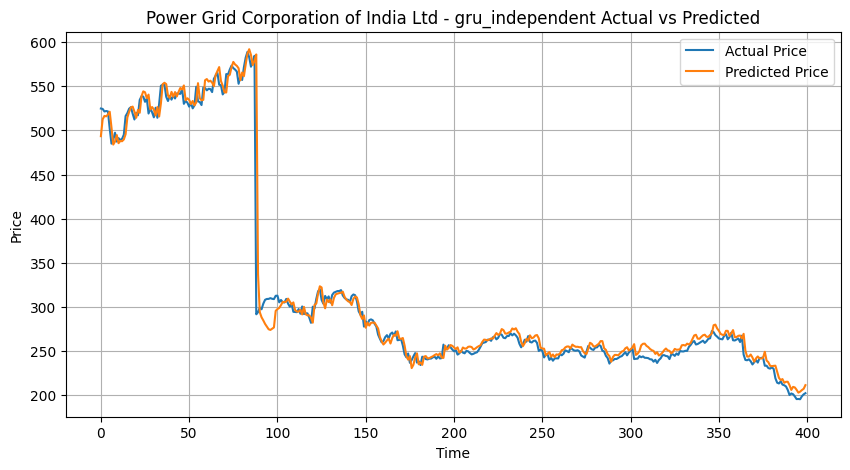

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Power_Grid_Corporation_of_India_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


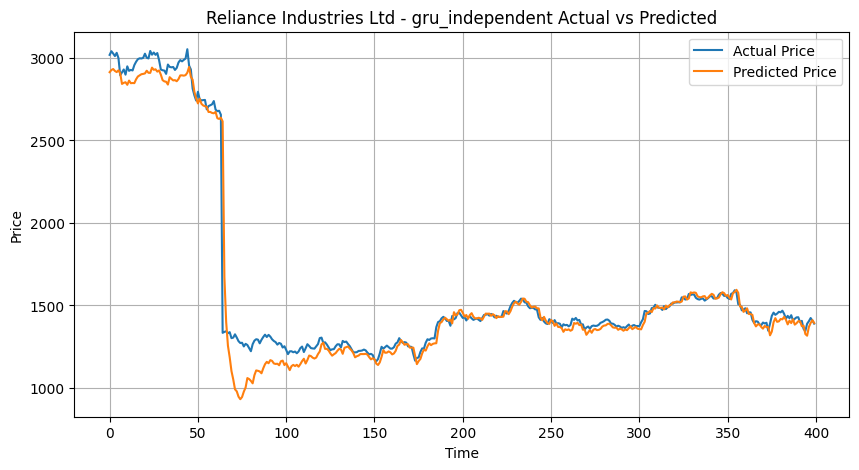

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Reliance_Industries_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


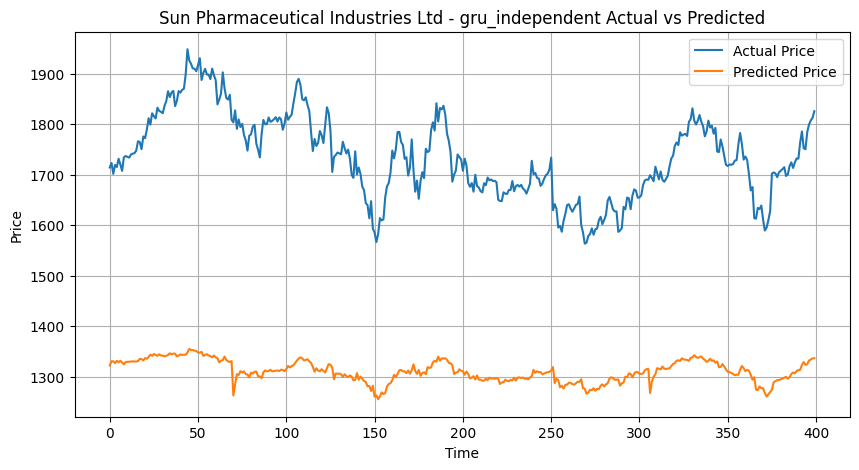

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Sun_Pharmaceutical_Industries_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


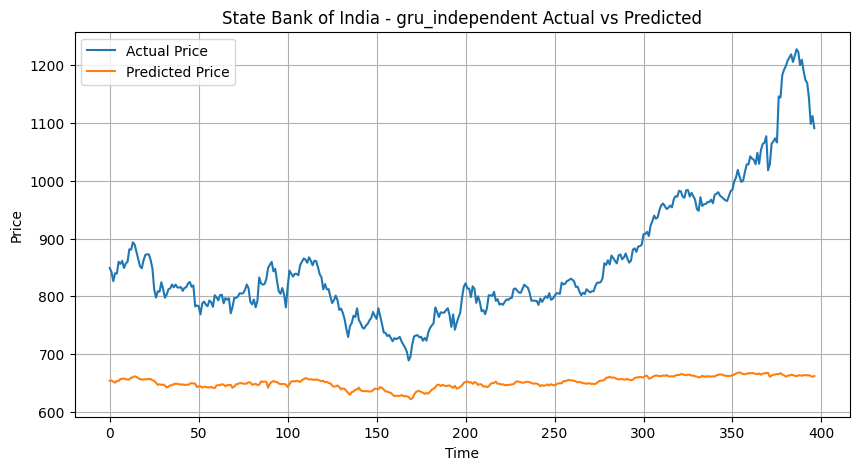

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/State_Bank_of_India_gru_independent_actual_vs_pred.png
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


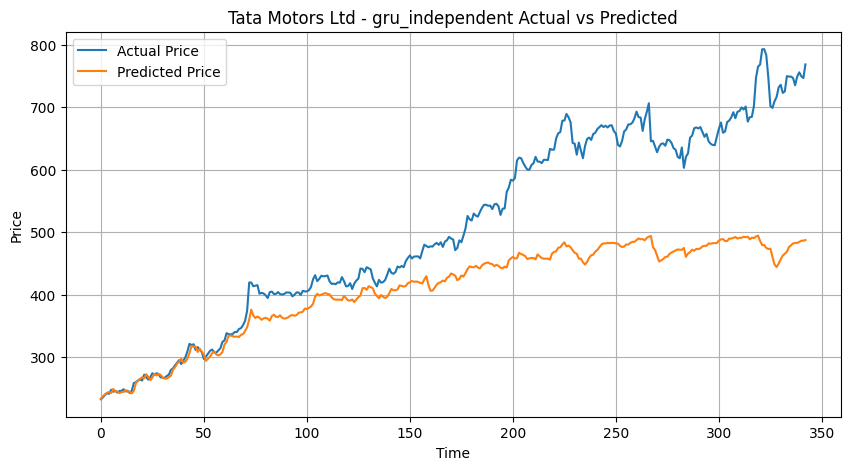

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Tata_Motors_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


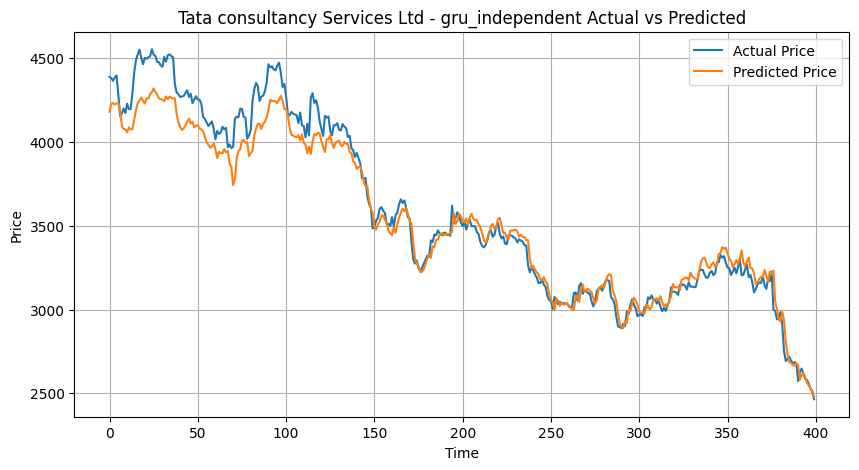

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Tata_consultancy_Services_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


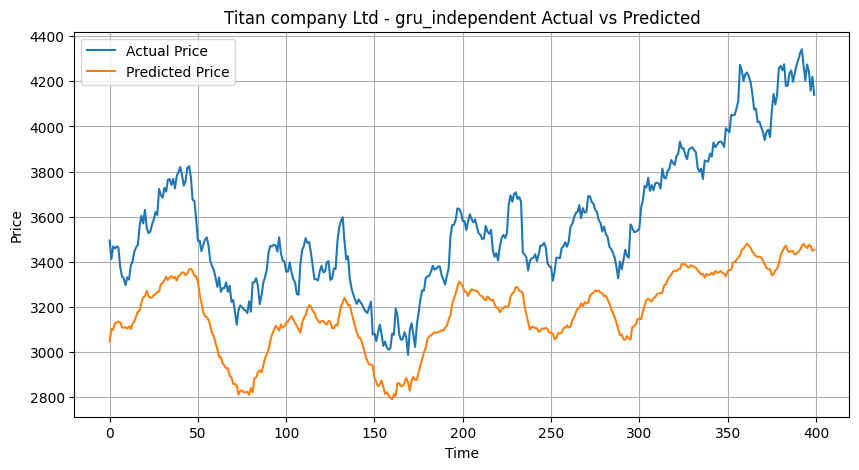

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Titan_company_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


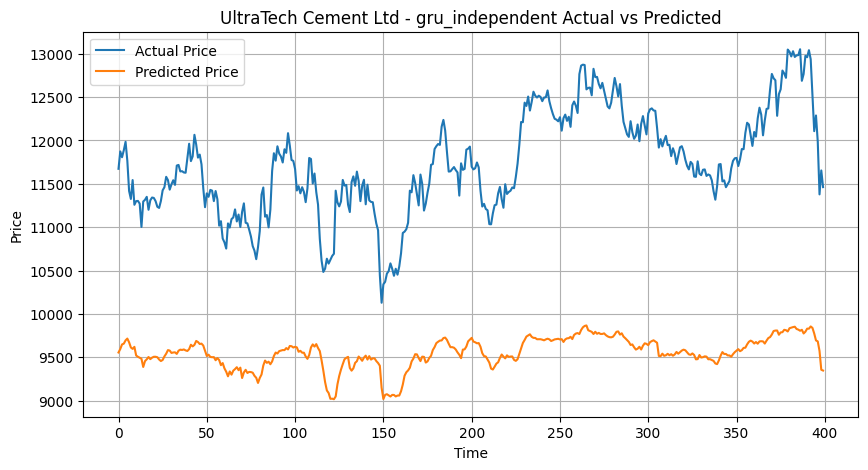

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/UltraTech_Cement_Ltd_gru_independent_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


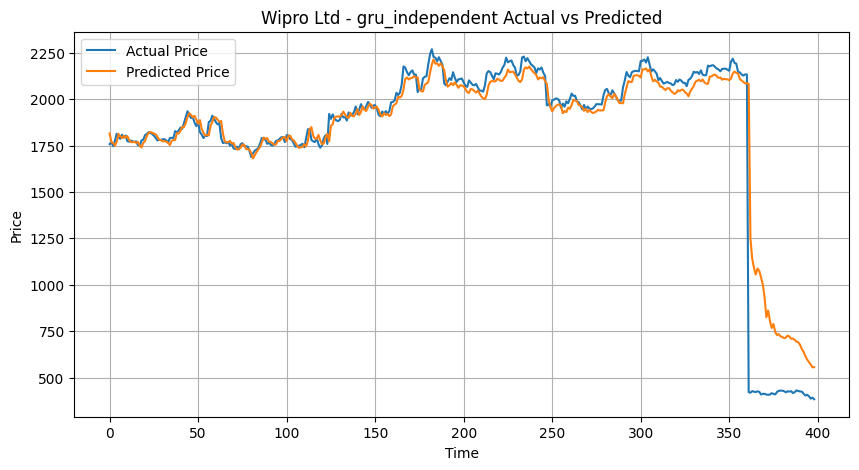

Plot saved at: /content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_plots/Wipro_Ltd_gru_independent_actual_vs_pred.png


In [ ]:
import matplotlib.pyplot as plt
import os

MODEL_TAG = "gru_independent"

for company, data in all_gru_models.items():

    model = data['gru_ind_model']   # GRU Independent model
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    # Predict
    y_pred = model.predict(X_test)

    # Inverse scale
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_test_inv, label="Actual Price")
    plt.plot(y_pred_inv, label="Predicted Price")

    plt.title(f"{company} - {MODEL_TAG} Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Price")

    plt.legend()
    plt.grid(True)

    # Save plot
    safe_name = company.replace(" ", "_").replace(".", "")
    plot_path = os.path.join(GRU_PLOT_DIR, f"{safe_name}_{MODEL_TAG}_actual_vs_pred.png")

    plt.savefig(plot_path)
    plt.show()

    print(f"Plot saved at: {plot_path}")

In [ ]:
# PREDICTION

from datetime import timedelta
import numpy as np
import pandas as pd

def predict_future_gru_ind(company, all_gru_models, processed_data, n_future=5):

    data = all_gru_models[company]

    model = data['gru_ind_model']          #  GRU Independent model
    feature_scaler = data['feature_scaler']
    target_scaler  = data['target_scaler']
    timesteps      = data['timesteps']
    feature_columns = data['feature_columns']   # taken from dict

    df = processed_data[company].copy()

    # -------- Scale features --------
    scaled_features = feature_scaler.transform(df[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):

        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        # Convert back to real value
        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        # -------- Update sequence --------
        next_row = current_seq[-1].copy()

        if 'Close' in feature_columns:
            next_row[feature_columns.index('Close')] = pred_scaled

        current_seq = np.vstack([current_seq[1:], next_row])

    # -------- Future dates --------
    future_dates = [
        df['Date'].iloc[-1] + timedelta(days=i+1)
        for i in range(n_future)
    ]

    return pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')

In [ ]:
all_gru_ind_predictions = {}

for company in all_gru_models.keys():

    pred_df = predict_future_gru_ind(
        company=company,
        all_gru_models=all_gru_models,
        processed_data=processed_data,
        n_future=5
    )

    all_gru_ind_predictions[company] = pred_df

    print(f"Future prediction done for {company}")

Future prediction done for Adani Enterprises Ltd
Future prediction done for Adani ports and special Economic
Future prediction done for Bajaj Finance Ltd
Future prediction done for Axis Bank Ltd
Future prediction done for Bajaj Finserv Ltd
Future prediction done for Bharat Electronics Ltd
Future prediction done for Bharti Airtel Ltd
Future prediction done for Eternal Ltd
Future prediction done for HCL Technologies Ltd
Future prediction done for HDFC Bank Ltd
Future prediction done for Hindustan Unilever Ltd
Future prediction done for ICICI Bank Ltd
Future prediction done for ITC Ltd
Future prediction done for Infosys Ltd
Future prediction done for JSW Steel Ltd
Future prediction done for Larsen and Toubro Ltd
Future prediction done for Kotak Mahindra Bank Ltd
Future prediction done for Mahindra and Mahindra Ltd
Future prediction done for Maruti Suzuki India Ltd
Future prediction done for NTPC Ltd
Future prediction done for Oil and Natural Gas Corporation Ltd
Future prediction done for 

In [ ]:
from datetime import timedelta
import numpy as np
import pandas as pd

n_future = 5
all_gru_ind_predictions = {}

close_index = feature_columns.index('Close')

for company, data in all_gru_models.items():

    model = data['gru_ind_model']
    feature_scaler = data['feature_scaler']
    target_scaler = data['target_scaler']
    timesteps = data['timesteps']

    df = processed_data[company].copy()

    scaled_features = feature_scaler.transform(df[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):
        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        next_row = current_seq[-1].copy()
        next_row[close_index] = pred_scaled
        current_seq = np.vstack([current_seq[1:], next_row])

    last_date = df['Date'].iloc[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(n_future)]

    pred_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')

    all_gru_ind_predictions[company] = pred_df   #  Separate dict

    print(f"{company} next {n_future} days predicted (gru_independent)")

Adani Enterprises Ltd next 5 days predicted (gru_independent)
Adani ports and special Economic next 5 days predicted (gru_independent)
Bajaj Finance Ltd next 5 days predicted (gru_independent)
Axis Bank Ltd next 5 days predicted (gru_independent)
Bajaj Finserv Ltd next 5 days predicted (gru_independent)
Bharat Electronics Ltd next 5 days predicted (gru_independent)
Bharti Airtel Ltd next 5 days predicted (gru_independent)
Eternal Ltd next 5 days predicted (gru_independent)
HCL Technologies Ltd next 5 days predicted (gru_independent)
HDFC Bank Ltd next 5 days predicted (gru_independent)
Hindustan Unilever Ltd next 5 days predicted (gru_independent)
ICICI Bank Ltd next 5 days predicted (gru_independent)
ITC Ltd next 5 days predicted (gru_independent)
Infosys Ltd next 5 days predicted (gru_independent)
JSW Steel Ltd next 5 days predicted (gru_independent)
Larsen and Toubro Ltd next 5 days predicted (gru_independent)
Kotak Mahindra Bank Ltd next 5 days predicted (gru_independent)
Mahindra 

In [ ]:
for company, pred in all_gru_ind_predictions.items():
    print(company)
    print(pred)
    print("-" * 40)

Adani Enterprises Ltd
            Predicted_Close
Date                       
2026-03-12      1950.635948
2026-03-13      1938.373944
2026-03-14      1936.936045
2026-03-15      1938.819532
2026-03-16      1940.076466
----------------------------------------
Adani ports and special Economic
            Predicted_Close
Date                       
2026-03-12       423.748958
2026-03-13       411.412338
2026-03-14       404.704747
2026-03-15       402.021133
2026-03-16       401.702718
----------------------------------------
Bajaj Finance Ltd
            Predicted_Close
Date                       
2026-03-12      1195.523120
2026-03-13      1186.555595
2026-03-14      1176.112987
2026-03-15      1168.296764
2026-03-16      1163.245384
----------------------------------------
Axis Bank Ltd
            Predicted_Close
Date                       
2026-03-12      1012.038294
2026-03-13       992.818655
2026-03-14       981.419237
2026-03-15       973.561311
2026-03-16       968.612934
------

In [ ]:
import os
import shutil
import pandas as pd

# Convert dictionary of predictions to a single DataFrame
final_pred_df = pd.concat(all_gru_ind_predictions, axis=1)
final_pred_df.columns = [col[0] for col in final_pred_df.columns]  # clean column labels
final_pred_df.index.name = 'Date'

# Main output file
output_path = "/content/drive/MyDrive/major_data/Future/GRU_INDEPENDENT/gru_future_predictions.csv"

# Ensure parent folder exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# If a directory accidentally exists with same name → remove it
if os.path.isdir(output_path):
    shutil.rmtree(output_path)

# Save combined predictions
final_pred_df.to_csv(output_path)

# Save individual company predictions
individual_folder = "/content/drive/MyDrive/major_data/Future/GRU_INDEPENDENT/gru__individual_predictions"
os.makedirs(individual_folder, exist_ok=True)

for company in final_pred_df.columns:
    company_safe = company.replace(" ", "_")

    company_df = final_pred_df[[company]]  # select single column
    company_df.to_csv(
        os.path.join(individual_folder, f"{company_safe}_future.csv")
    )

print(f"Combined file saved: {output_path}")
print(f"Individual company files saved in: {individual_folder}")

Combined file saved: /content/drive/MyDrive/major_data/Future/GRU_INDEPENDENT/gru_future_predictions.csv
Individual company files saved in: /content/drive/MyDrive/major_data/Future/GRU_INDEPENDENT/gru__individual_predictions


In [ ]:
# RECOMMENDATION / RANKING

def expected_return(last_price, future_price):
    return ((future_price - last_price) / last_price) * 100

In [ ]:
gru_independent_ranking = []

for company in all_gru_models.keys():

    pred_df = predict_future_gru_ind(
        company,
        all_gru_models,
        processed_data,
        n_future=5
    )

    last_close = processed_data[company]['Close'].iloc[-1]
    future_close = pred_df['Predicted_Close'].iloc[-1]

    ret = expected_return(last_close, future_close)

    gru_independent_ranking.append({
        'Company': company,
        'Last_Close': round(last_close, 2),
        'Predicted_Close_5D': round(future_close, 2),
        'Expected_Return_%': round(ret, 2)
    })

# Create DataFrame
ranking_df_gru = pd.DataFrame(gru_independent_ranking)

# Sort by expected return
ranking_df_gru = ranking_df_gru.sort_values(by='Expected_Return_%', ascending=False)

# Take TOP 10
top10_gru = ranking_df_gru.head(10).reset_index(drop=True)

# Add Rank column
top10_gru.insert(0, 'Rank', range(1, len(top10_gru) + 1))

# Display
top10_gru

,Rank,Company,Last_Close,Predicted_Close_5D,Expected_Return_%
0,1,Wipro Ltd,383.20,573.04,49.54
1,2,Bajaj Finance Ltd,893.65,1163.25,30.17
2,3,HDFC Bank Ltd,833.95,927.20,11.18
3,4,Power Grid Corporation of India Ltd,202.23,216.77,7.19
4,5,Eternal Ltd,1178.80,1216.33,3.18
5,6,Oil and Natural Gas Corporation Ltd,270.75,278.33,2.80
6,7,ITC Ltd,309.00,313.16,1.35
7,8,Larsen and Toubro Ltd,309.00,309.37,0.12
8,9,Hindustan Unilever Ltd,2161.40,2148.91,-0.58
9,10,Adani Enterprises Ltd,1974.70,1940.08,-1.75


In [ ]:
import os
import pandas as pd

# Path to existing folder
GRU_RANKING_DIR = "/content/drive/MyDrive/major_data/Ranking"

# Create DataFrame (from GRU ranking list)
ranking_df_gru = pd.DataFrame(gru_independent_ranking)

# Sort by expected return
ranking_df_gru = ranking_df_gru.sort_values(
    by='Expected_Return_%',
    ascending=False
).reset_index(drop=True)

# Save file
file_path = os.path.join(GRU_RANKING_DIR, "GRU_Independent_top_ranking.csv")
ranking_df_gru.to_csv(file_path, index=False)

print(f" Ranking saved successfully at:\n{file_path}")

 Ranking saved successfully at:
/content/drive/MyDrive/major_data/Ranking/GRU_Independent_top_ranking.csv


In [ ]:
import os
import pandas as pd

# Create folder for saving GRU Model2 test results
PRED_RESULTS_DIR_GRU = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_independent_predicted_prices"
os.makedirs(PRED_RESULTS_DIR_GRU, exist_ok=True)

# Save predicted vs actual for each company (test set)
for company, data in all_gru_models.items():

    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    # Predict using GRU independent model
    y_pred_scaled = data['gru_ind_model'].predict(X_test)

    # Convert back to original scale
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    # Create results dataframe
    test_df = pd.DataFrame({
        'Actual_Close': y_true.flatten(),
        'Predicted_Close': y_pred.flatten()
    })

    # Save file per company
    file_path = os.path.join(
        PRED_RESULTS_DIR_GRU,
        f"{company.replace(' ', '_')}_test_results.csv"
    )

    test_df.to_csv(file_path, index=False)
    print(f" Test results saved for {company} (GRU independent)")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
 Test results saved for Adani Enterprises Ltd (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
 Test results saved for Adani ports and special Economic (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
 Test results saved for Bajaj Finance Ltd (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for Axis Bank Ltd (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for Bajaj Finserv Ltd (GRU independent)
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
 Test results saved for Bharat Electronics Ltd (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for Bharti Airtel Ltd (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
 Test results saved for Eternal Ltd (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for HCL Technologies Ltd (GRU independent)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for HDFC Bank Ltd (GRU in

In [ ]:
import os
import json
import joblib
from tensorflow.keras.models import load_model

GRU_IND_MODEL_DIR = "/content/drive/MyDrive/major_data/GRU_INDEPENDENT/gru_models_independent"

gru_ind_model = {}

for company_folder in os.listdir(GRU_IND_MODEL_DIR):

    company_path = os.path.join(GRU_IND_MODEL_DIR, company_folder)

    if os.path.isdir(company_path):

        company_name = company_folder.replace("_", " ")

        # Load GRU model
        model = load_model(os.path.join(company_path, "gru_ind_model.keras"))

        # Load scalers
        feature_scaler = joblib.load(
            os.path.join(company_path, "feature_scaler.pkl")
        )

        target_scaler = joblib.load(
            os.path.join(company_path, "target_scaler.pkl")
        )

        # Load metadata
        with open(os.path.join(company_path, "metadata.json"), "r") as f:
            metadata = json.load(f)

        gru_ind_model[company_name] = {
            "model": model,
            "feature_scaler": feature_scaler,
            "target_scaler": target_scaler,
            "timesteps": metadata["timesteps"],
            "feature_columns": metadata["feature_columns"]
        }

        print(f"Loaded GRU independent model for {company_name}")

print("\nAll GRU independent models loaded successfully!")

Loaded GRU independent model for Adani Enterprises Ltd
Loaded GRU independent model for Adani ports and special Economic
Loaded GRU independent model for Bajaj Finance Ltd
Loaded GRU independent model for Axis Bank Ltd
Loaded GRU independent model for Bajaj Finserv Ltd
Loaded GRU independent model for Bharat Electronics Ltd
Loaded GRU independent model for Bharti Airtel Ltd
Loaded GRU independent model for Eternal Ltd
Loaded GRU independent model for HCL Technologies Ltd
Loaded GRU independent model for HDFC Bank Ltd
Loaded GRU independent model for Hindustan Unilever Ltd
Loaded GRU independent model for ICICI Bank Ltd
Loaded GRU independent model for ITC Ltd
Loaded GRU independent model for Infosys Ltd
Loaded GRU independent model for JSW Steel Ltd
Loaded GRU independent model for Larsen and Toubro Ltd
Loaded GRU independent model for Kotak Mahindra Bank Ltd
Loaded GRU independent model for Mahindra and Mahindra Ltd
Loaded GRU independent model for Maruti Suzuki India Ltd
Loaded GRU i